In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [12]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    category:str

In [13]:
def calculate_bmi(state: BMIState) -> BMIState:
    """Calculate BMI based on weight and height."""
    weight = state['weight']
    height = state['height']

    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi,2)
    return state

In [14]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 29.9:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obesity'
    return state


In [22]:
def outer_function(state: BMIState) -> BMIState:
    """A placeholder for any additional processing."""
    # For now, just return the state as is.
    return state

In [23]:
graph = StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label',label_bmi)
graph.add_node('outer',outer_function)
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label')
graph.add_edge('label', END)
workflow = graph.compile()

In [19]:
workflow.invoke({'weight':70 , 'height':1.75})

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}

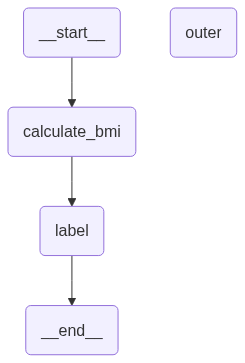

In [24]:
from IPython.display import Image, display 
display(Image(workflow.get_graph().draw_mermaid_png()))